# Module 05 - Customer Behavior, Demand Forecasting, and Recommendation

Notebook này mở rộng phần phân tích dữ liệu rác/synthetic thành nội
dung học thuật: audit tính giả lập, kiểm định giả thiết, xu hướng
nhu cầu, staffing theo giờ, preference size/type/restaurant/location,
recommendation rule và sales-volume reporting.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
from pizza_dss.business_analysis import (
    build_business_artifacts,
    customer_preference_tables,
    forecast_method_comparison,
    forecast_metrics,
    forecast_monthly_demand,
    hourly_staffing_plan,
    hypothesis_tests,
    monthly_demand,
    monthly_product_trends,
    preference_trend_tests,
    recommendation_rules,
    redundant_feature_audit,
    synthetic_data_audit,
)
from pizza_dss.data_loader import load_dataset
from IPython.display import Image

Sinh trước hình business để hiển thị inline.

In [2]:
_ = build_business_artifacts()

## 0. Định nghĩa thuật ngữ business

- **MAE**: sai số tuyệt đối trung bình (đơn vị: số đơn). **MAPE**: sai
  số phần trăm tuyệt đối trung bình; >40% = forecast yếu.
- **Seasonal-naive**: dự báo tháng t bằng giá trị cùng kỳ năm trước.
  **Moving average**: trung bình vài tháng gần nhất.
- **Mann-Kendall**: kiểm định xu hướng phi tham số; `tau` là cường độ xu
  hướng, `p < 0.05` mới kết luận có trend (tăng/giảm).
- **Confidence/Support** của recommendation rule: P(gợi ý | bối cảnh) và
  tần suất bối cảnh.
- **order_share**: tỷ trọng đơn của một size/type trên tổng.

## 1. Data realism / synthetic audit

In [3]:
df = load_dataset()
synthetic_data_audit(df)

,check,severity,evidence,interpretation
0,No missing values,warning,0 missing cells across 37 columns,"Clean data is useful, but a zero-missing opera..."
1,Future timestamp relative to analysis date,warning,"max order_time=2026-07-07 20:00:00, analysis_d...","The file title says 2024-25, but rows reach Ju..."
2,Label is deterministic from delivery duration,critical,True,"delivery_duration_min, delay_min and delivery_..."
3,Estimated duration formula,warning,max |estimated_duration_min - 2.4 * distance_k...,estimated_duration_min is a deterministic tran...
4,Topping density formula,warning,max |topping_density - toppings_count / distan...,topping_density duplicates information already...
5,Pizza complexity formula,warning,max |pizza_complexity - toppings_count * size_...,pizza_complexity is engineered from toppings_c...
6,Traffic impact is only encoded traffic level,warning,"unique traffic_impact values=[1, 2, 3]",traffic_impact is redundant with traffic_level.
7,Delivery duration has few discrete values,warning,"8 unique values: [15, 20, 25, 30, 35, 40, 45, 50]",Real delivery duration usually has richer minu...
8,Order hour support is narrow,warning,8 unique hours; 94.2% are 18-20h,This is useful for dinner-peak staffing but to...
9,Distance support is discretized,warning,25 unique distances across 1004 rows,Distances look sampled from a short menu of va...


In [4]:
redundant_feature_audit(df)

,column,source_or_formula,max_abs_error,model_action
0,estimated_duration_min,2.4 * distance_km,3.552714e-15,Drop in compact feature set; keep distance_km.
1,topping_density,toppings_count / distance_km,2.220446e-16,Drop in compact feature set; keep base variables.
2,pizza_complexity,toppings_count * pizza_size_score,0.000000e+00,Use for interpretation; compact model uses siz...
3,traffic_impact,"Low=1, Medium=2, High=3",0.000000e+00,Drop in compact feature set; keep traffic_level.
4,delay_min,delivery_duration_min - estimated_duration_min,3.552714e-15,Block as leakage.
5,delivery_efficiency_min_per_km,delivery_duration_min / distance_km,0.000000e+00,Block as leakage.
6,restaurant_avg_time,group statistic from delivery duration,NaN,Block as post-hoc aggregate leakage.


Kết luận: dữ liệu có nhiều cột deterministic. Vì vậy dự án không cố
che điểm yếu này mà đưa nó vào audit, đồng thời tạo feature set
compact để so sánh với feature set đầy đủ.

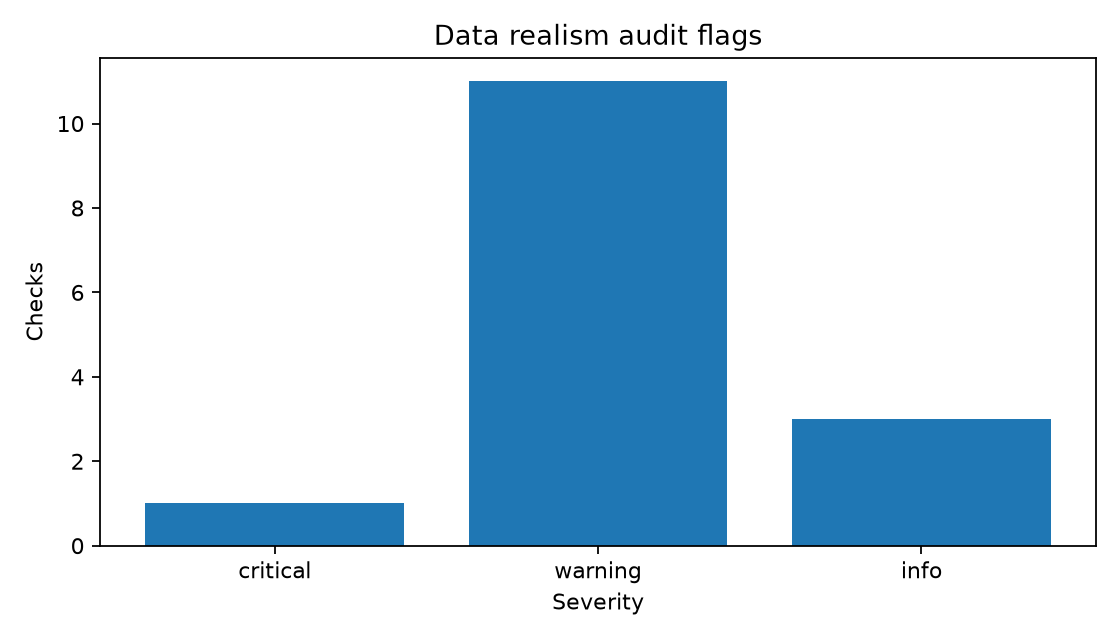

In [5]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "synthetic_data_flags.png"))

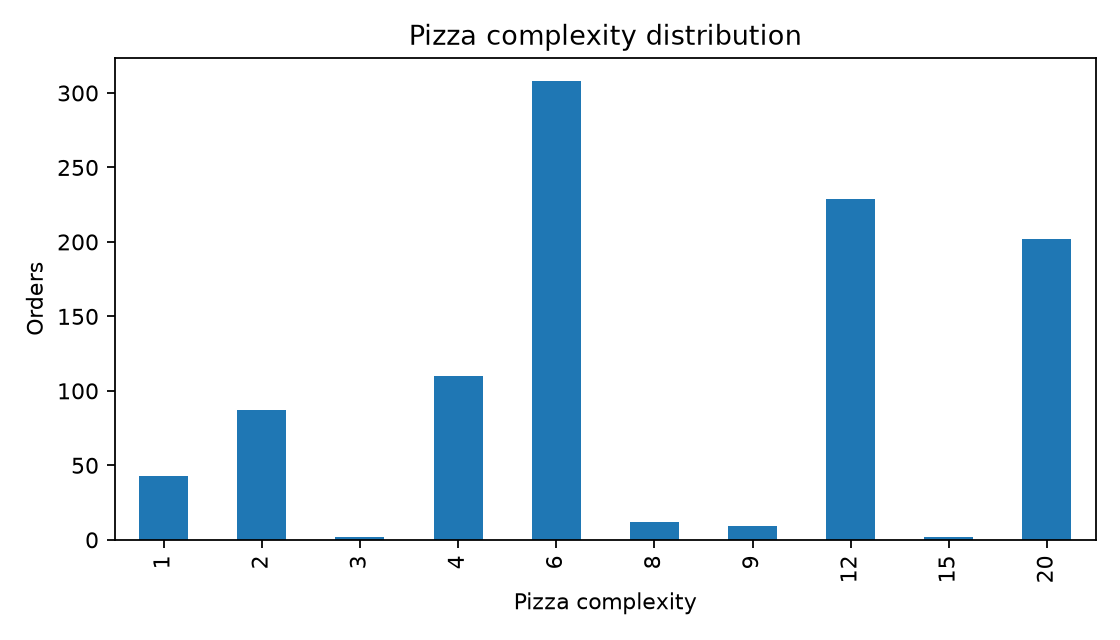

In [6]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "complexity_distribution.png"))

## 2. Hypothesis tests

In [7]:
hypothesis_tests(df)

,variable,test,rows,chi2,dof,p_value,cramers_v,min_expected,significant_at_0_05,interpretation
4,traffic_level,chi-square independence vs is_delayed,3,265.676749,2,2.037168e-58,0.514411,58.147410,True,Evidence of association with delay
3,pizza_type,chi-square independence vs is_delayed,12,186.022262,11,5.842823e-34,0.430443,0.418327,True,Evidence of association with delay
0,payment_method,chi-square independence vs is_delayed,6,176.028340,5,3.771418e-36,0.418721,4.810757,True,Evidence of association with delay
8,complexity_band,chi-square independence vs is_delayed,4,151.234790,3,1.426896e-32,0.388114,42.669323,True,Evidence of association with delay
2,pizza_size,chi-square independence vs is_delayed,4,148.199282,3,6.444649e-32,0.384199,27.609562,True,Evidence of association with delay
6,location_top12,chi-square independence vs is_delayed,13,142.016354,12,2.344926e-24,0.376099,7.739044,True,Evidence of association with delay
5,restaurant_name,chi-square independence vs is_delayed,5,18.187573,4,1.134156e-03,0.134592,40.577689,True,Evidence of association with delay
7,time_segment,chi-square independence vs is_delayed,3,14.442731,2,7.308037e-04,0.119938,0.627490,True,Evidence of association with delay
1,payment_category,chi-square independence vs is_delayed,2,0.947863,1,3.302639e-01,0.030726,52.081673,False,No strong evidence of association with delay


Kiểm định chi-square trả lời các câu hỏi kiểu: payment method,
pizza size, traffic, restaurant, location top-12 có độc lập với
trạng thái delayed hay không. Với dữ liệu synthetic, p-value chỉ là
minh chứng phân tích, không được diễn giải như bằng chứng nhân quả.

## 3. Customer preferences

In [8]:
prefs = customer_preference_tables(df)
prefs["size_mix"]

,pizza_size_score,pizza_size_label,pizza_size,count,delayed,delay_rate,order_share
0,1,01_Small,Small,132,2,0.015152,0.131474
1,2,02_Medium,Medium,429,39,0.090909,0.427291
2,3,03_Large,Large,240,85,0.354167,0.239044
3,4,04_XL,XL,203,84,0.413793,0.202191


In [9]:
prefs["type_mix"].head(12)

,pizza_type,count,delayed,delay_rate,order_share
5,Non-Veg,216,45,0.208333,0.215139
10,Veg,202,44,0.217822,0.201195
1,Cheese Burst,188,67,0.356383,0.187251
11,Vegan,132,3,0.022727,0.131474
6,Sicilian,64,6,0.093750,0.063745
4,Margarita,54,0,0.000000,0.053785
0,BBQ Chicken,54,0,0.000000,0.053785
3,Gluten-Free,41,22,0.536585,0.040837
8,Thai Chicken,24,3,0.125000,0.023904
7,Stuffed Crust,21,20,0.952381,0.020916


In [10]:
prefs["top_restaurant_by_type"]

,pizza_type,restaurant_name,orders,share_within_type
25,Veg,Domino's,106,0.524752
2,Cheese Burst,Little Caesars,93,0.494681
12,Non-Veg,Marco's Pizza,88,0.407407
15,Sicilian,Domino's,59,0.921875
0,BBQ Chicken,Papa John's,54,1.000000
9,Margarita,Marco's Pizza,54,1.000000
32,Vegan,Papa John's,47,0.356061
8,Gluten-Free,Papa John's,37,0.902439
23,Thai Chicken,Marco's Pizza,20,0.833333
19,Stuffed Crust,Little Caesars,13,0.619048


In [11]:
prefs["location_summary"].head(15)

,location,orders,delayed,delay_rate,avg_distance_km,top_type,top_size
4,"Atlanta, GA",78,4,0.051282,4.015385,Veg,Medium
49,"Milwaukee, WI",71,3,0.042254,4.577465,Margarita,Medium
43,"Louisville, KY",69,2,0.028986,5.978261,Cheese Burst,XL
58,"Omaha, NE",68,2,0.029412,5.029412,BBQ Chicken,Medium
1,"Albuquerque, NM",59,2,0.033898,5.491525,Sicilian,Large
11,"Boston, MA",51,17,0.333333,4.843137,Non-Veg,Small
19,"Dallas, TX",50,4,0.080000,3.930000,Non-Veg,Medium
48,"Miami, FL",49,12,0.244898,4.495918,Veg,Medium
20,"Denver, CO",46,8,0.173913,3.902174,Vegan,Small
14,"Chicago, IL",45,3,0.066667,4.355556,Non-Veg,Medium


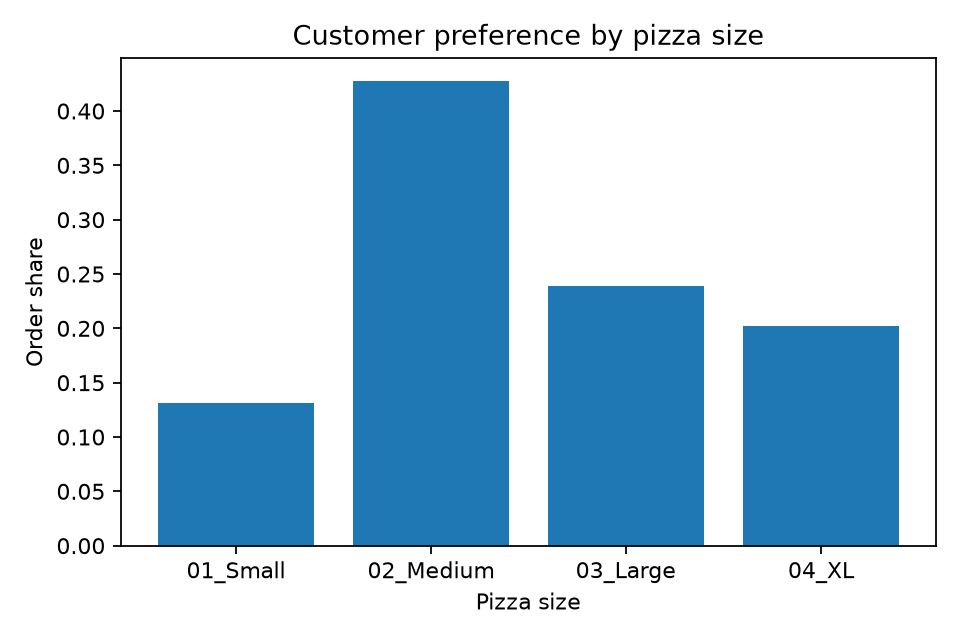

In [12]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "size_preference.png"))

## 4. Time series demand and staffing

In [13]:
monthly_demand(df).tail(15)

,order_period,orders,delayed,delay_rate,avg_distance_km,month_start,is_partial_month
16,2025-05,31,17,0.548387,5.693548,2025-05-01,False
17,2025-06,50,26,0.520000,5.654000,2025-06-01,False
18,2025-07,11,6,0.545455,5.590909,2025-07-01,False
19,2025-08,31,12,0.387097,5.129032,2025-08-01,False
20,2025-09,30,2,0.066667,5.100000,2025-09-01,False
21,2025-10,31,0,0.000000,5.032258,2025-10-01,False
22,2025-11,30,0,0.000000,5.000000,2025-11-01,False
23,2025-12,39,0,0.000000,5.038462,2025-12-01,False
24,2026-01,31,0,0.000000,5.000000,2026-01-01,False
25,2026-02,28,0,0.000000,5.017857,2026-02-01,False


In [14]:
forecast = forecast_monthly_demand(df, horizon=6)
forecast.tail(12)

,order_period,month_start,actual_orders,forecast_orders,split,method,is_partial_month
25,2026-02,2026-02-01,28.0,28.0,backtest,seasonal_naive_prior_year,False
26,2026-03,2026-03-01,31.0,31.0,backtest,seasonal_naive_prior_year,False
27,2026-04,2026-04-01,30.0,30.0,backtest,seasonal_naive_prior_year,False
28,2026-05,2026-05-01,31.0,31.0,backtest,seasonal_naive_prior_year,False
29,2026-06,2026-06-01,30.0,50.0,backtest,seasonal_naive_prior_year,False
30,2026-07,2026-07-01,7.0,11.0,backtest,seasonal_naive_prior_year,True
31,2026-08,2026-08-01,NaN,31.0,future,seasonal_naive_prior_year,False
32,2026-09,2026-09-01,NaN,30.0,future,seasonal_naive_prior_year,False
33,2026-10,2026-10-01,NaN,31.0,future,seasonal_naive_prior_year,False
34,2026-11,2026-11-01,NaN,30.0,future,seasonal_naive_prior_year,False


In [15]:
forecast_metrics(forecast)

{'backtest_rows': 19,
 'mae': 12.211,
 'mape': 0.457,
 'method': 'seasonal_naive_prior_year',
 'warning': 'Synthetic and partial-month data make this a planning demo, not a production forecast.'}

**So sánh phương pháp forecast** (backtest seasonal-naive vs moving-average):

In [16]:
forecast_method_comparison(df)

,method,backtest_points,mae,mape
0,seasonal_naive_prior_year,19,12.211,0.457
1,moving_average_3,28,12.048,0.590


**Insight (forecast).** Cả hai phương pháp đều có MAPE cao trên dữ liệu
nhỏ/synthetic + tháng partial; không phương pháp nào thắng rõ. Kết luận:
forecast chỉ là **demo quy trình planning**, không cam kết độ chính xác
sản xuất. Báo cáo phải nêu giới hạn này thay vì khoe MAPE.

In [17]:
hourly_staffing_plan(df).query("orders > 0").sort_values("scenario_orders_per_day", ascending=False)

,order_hour,orders,order_share,scenario_orders_per_day,recommended_staff,time_segment
19,19,328.0,0.326693,32.669323,3,Dinner
18,18,312.0,0.310757,31.075697,3,Dinner
20,20,306.0,0.304781,30.478088,3,Dinner
13,13,43.0,0.042829,4.282869,1,Lunch
14,14,6.0,0.005976,0.597610,1,Lunch
17,17,4.0,0.003984,0.398406,1,Dinner
21,21,3.0,0.002988,0.298805,1,Late
12,12,2.0,0.001992,0.199203,1,Lunch


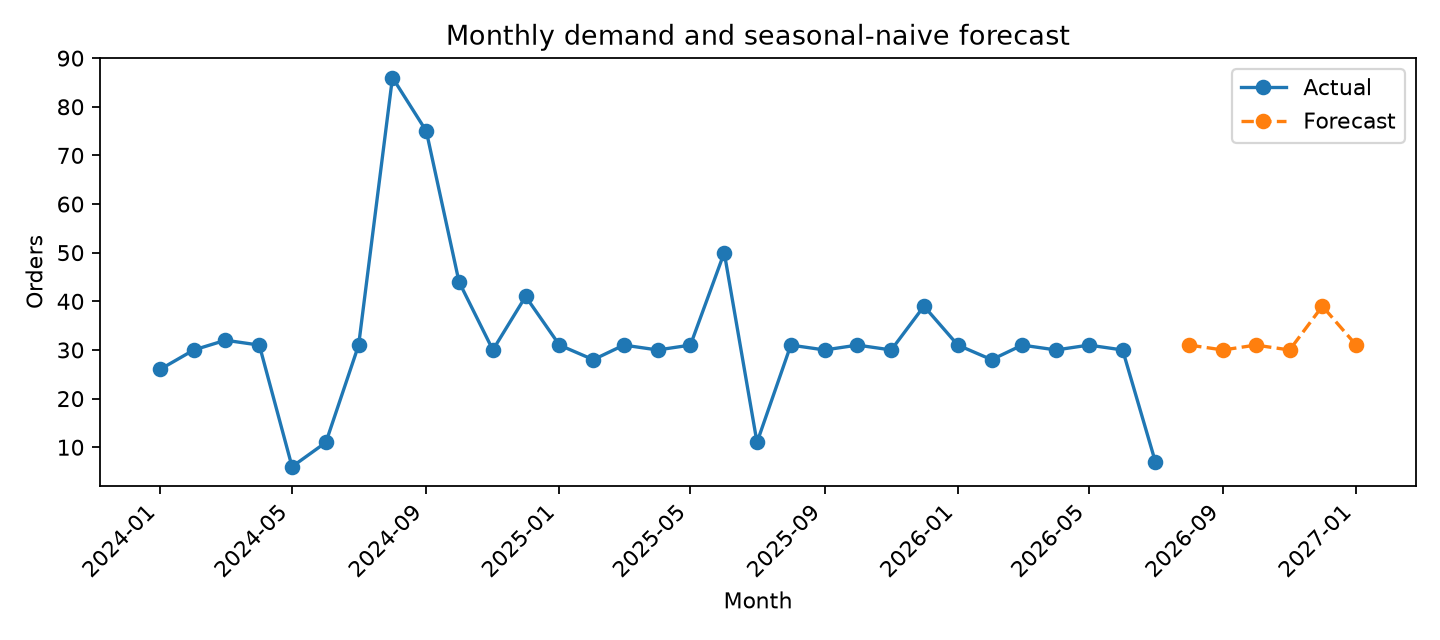

In [18]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "monthly_demand_forecast.png"))

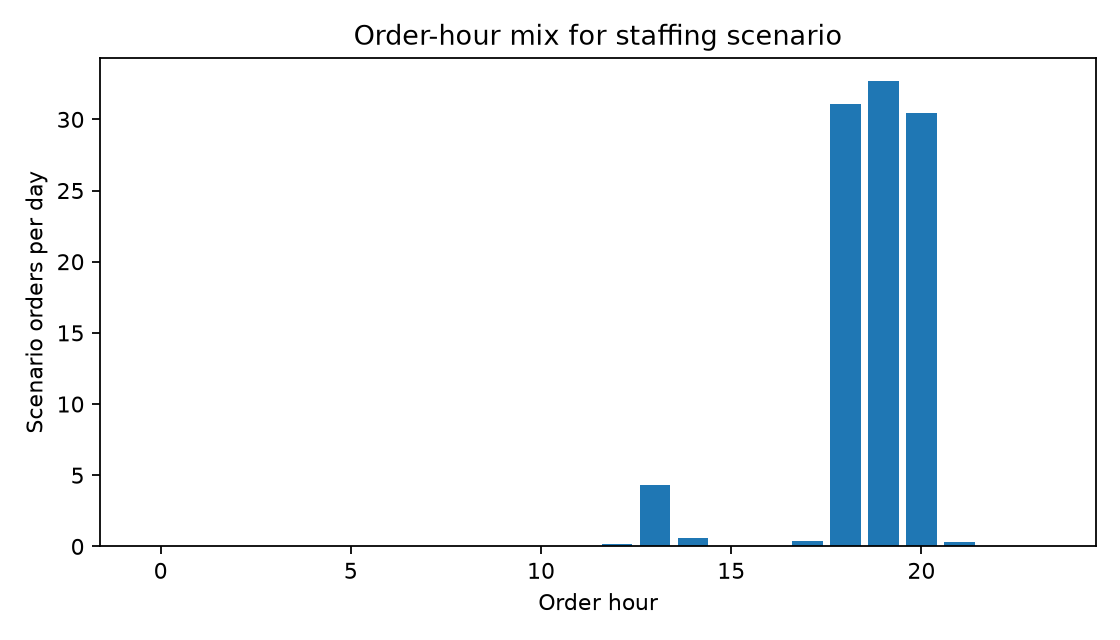

In [19]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "hourly_staffing_plan.png"))

## 5. Trend by product and recommendation

In [20]:
type_trend, size_trend = monthly_product_trends(df)
type_trend.sort_values(["order_period", "orders"], ascending=[False, False]).head(20)

,order_period,pizza_type,orders,share_within_month
170,2026-07,Cheese Burst,2,0.285714
171,2026-07,Margarita,2,0.285714
169,2026-07,BBQ Chicken,1,0.142857
172,2026-07,Sicilian,1,0.142857
173,2026-07,Veg,1,0.142857
164,2026-06,BBQ Chicken,7,0.233333
165,2026-06,Cheese Burst,6,0.200000
166,2026-06,Margarita,6,0.200000
168,2026-06,Veg,6,0.200000
167,2026-06,Sicilian,5,0.166667


**Kiểm định xu hướng sở thích (Mann-Kendall)** — có trend thật về sau không?

In [21]:
preference_trend_tests(df)

,dimension,category,months,tau,p_value,trend
0,pizza_size,01_Small,20,-0.1368,0.4173,no_trend
1,pizza_size,02_Medium,31,0.3333,0.0089,increasing
2,pizza_size,03_Large,31,-0.1892,0.1392,no_trend
3,pizza_size,04_XL,31,0.3097,0.0151,increasing
4,pizza_type,BBQ Chicken,9,-0.0556,0.9170,no_trend
5,pizza_type,Cheese Burst,31,0.2430,0.0570,no_trend
6,pizza_type,Deep Dish,4,-0.6667,0.3082,no_trend
7,pizza_type,Gluten-Free,13,0.4359,0.0441,increasing
8,pizza_type,Margarita,9,0.3333,0.2515,no_trend
9,pizza_type,Non-Veg,21,-0.7048,0.0000,decreasing


**Insight (trend).** Hầu hết category có `trend = no_trend` (p ≥ 0.05):
share size/type **không** có xu hướng tăng/giảm có ý nghĩa. Đây là câu
trả lời trung thực cho "dự đoán trend về sau?": *forecast được về mặt cơ
học, nhưng dữ liệu không cho thấy trend thực để dự báo* — đúng bản chất
dữ liệu random.

In [22]:
recommendation_rules(df).head(20)

,rule_type,context,recommendation,context_orders,matched_orders,confidence
48,Most chosen restaurant for same pizza type,pizza_type=BBQ Chicken,restaurant_name=Papa John's,54,54,1.000000
51,Most chosen restaurant for same pizza type,pizza_type=Margarita,restaurant_name=Marco's Pizza,54,54,1.000000
15,Top pizza type by restaurant and size,"restaurant_name=Papa John's, pizza_size=Small",pizza_type=Vegan,47,47,1.000000
8,Top pizza type by restaurant and size,"restaurant_name=Little Caesars, pizza_size=Small",pizza_type=Vegan,43,43,1.000000
18,Top pizza type by restaurant and size,"restaurant_name=Pizza Hut, pizza_size=Small",pizza_type=Vegan,23,23,1.000000
42,Preferred restaurant by location,"location=Omaha, NE",restaurant_name=Papa John's,68,67,0.985294
17,Top pizza type by restaurant and size,"restaurant_name=Pizza Hut, pizza_size=Medium",pizza_type=Veg,65,64,0.984615
7,Top pizza type by restaurant and size,"restaurant_name=Little Caesars, pizza_size=Medium",pizza_type=Non-Veg,46,45,0.978261
37,Preferred restaurant by location,"location=Louisville, KY",restaurant_name=Little Caesars,69,67,0.971014
59,Top size by time segment,time_segment=Lunch,pizza_size=Medium,51,49,0.960784


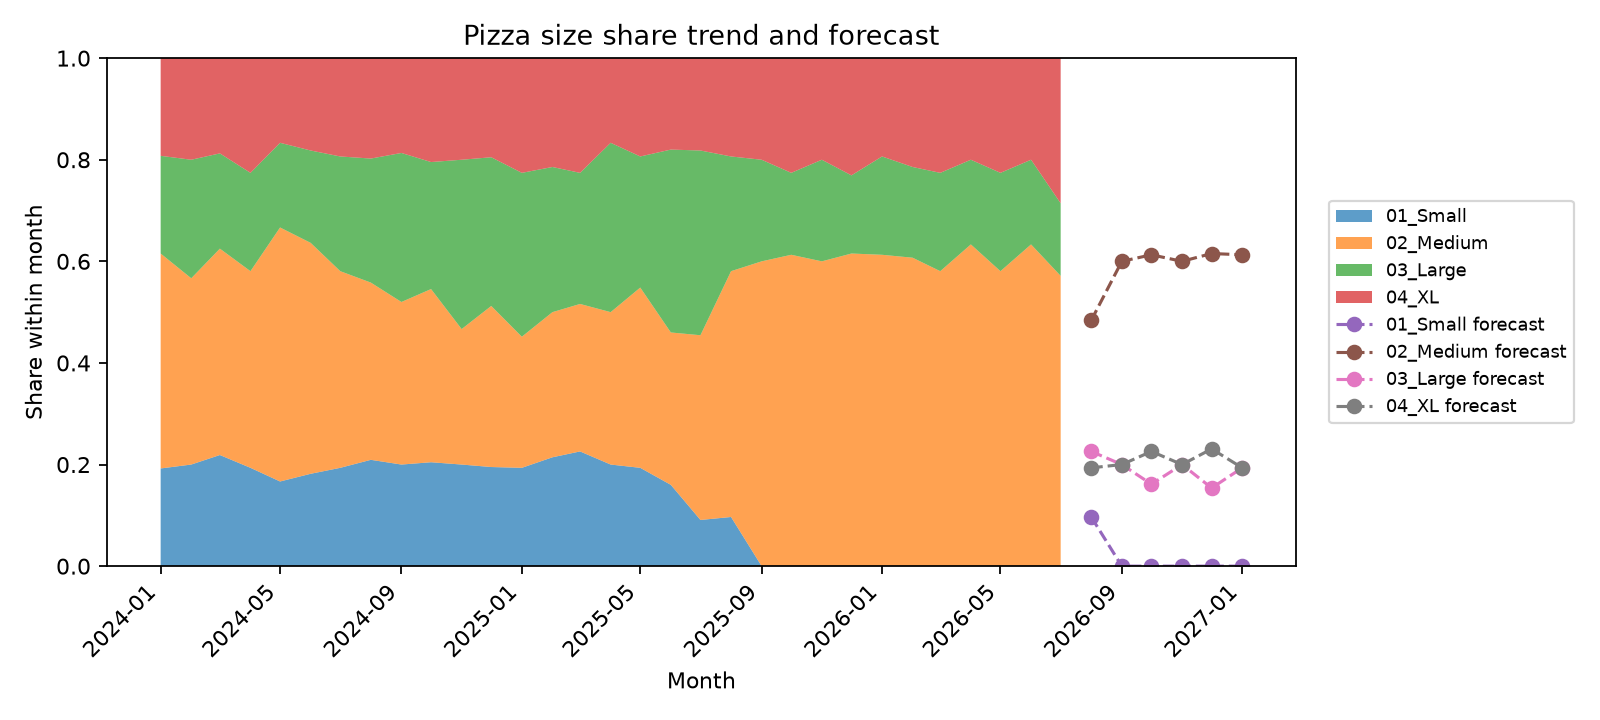

In [23]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "preference_size_share_forecast.png"))

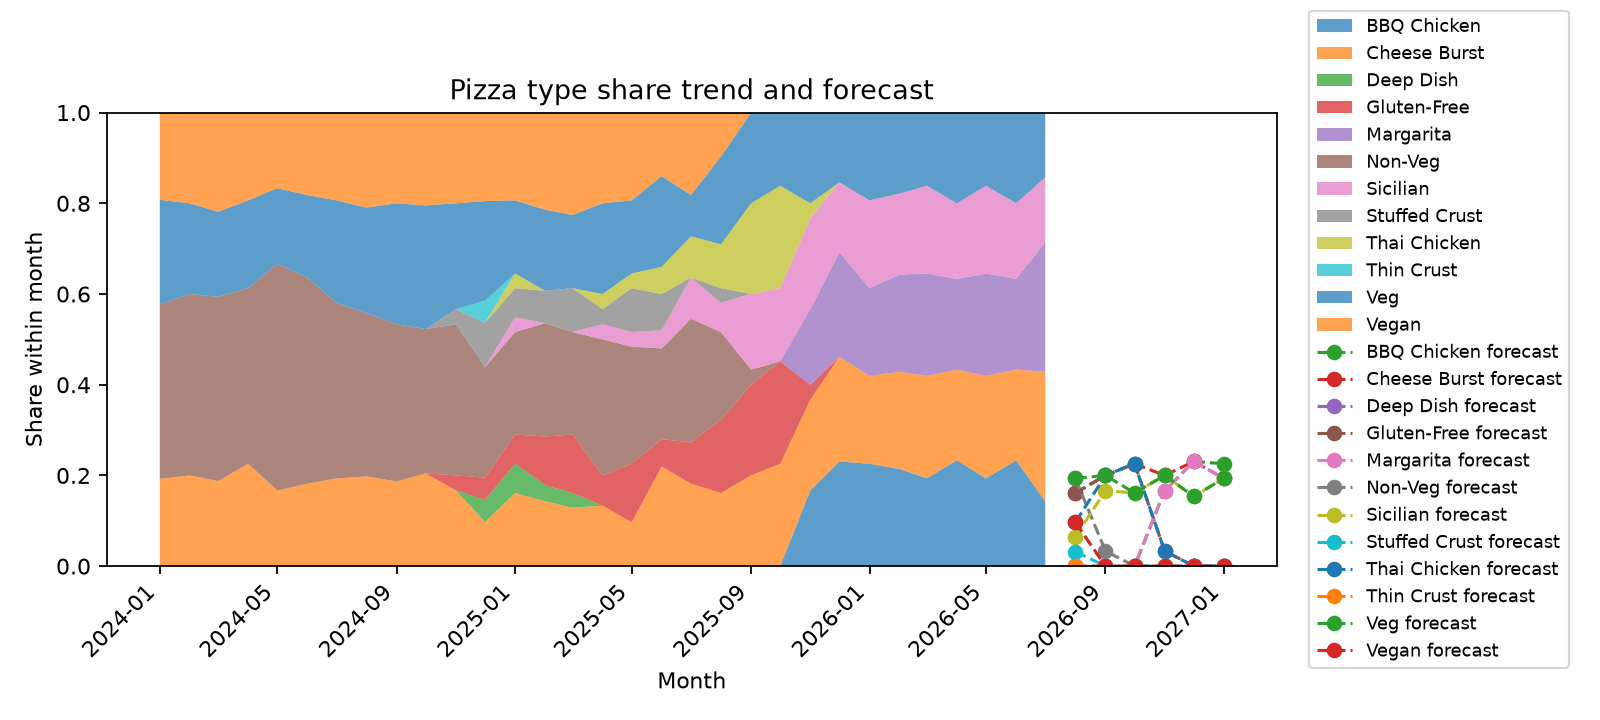

In [24]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "preference_type_share_forecast.png"))

## 6. Insight → quyết định

In [25]:
pd.DataFrame([
    {
        "module": "Customer preference",
        "insight": "Medium và Non-Veg có order share cao nhất; một số combo type-size có delay rate cao.",
        "decision": "Dùng trong dashboard mix sản phẩm và rule recommendation, không dùng làm kết luận thị trường thật.",
    },
    {
        "module": "Demand forecast",
        "insight": "Seasonal-naive forecast có MAPE cao do dữ liệu nhỏ/synthetic và tháng partial.",
        "decision": "Chỉ dùng forecast như minh họa staffing/planning, không cam kết dự báo sản xuất.",
    },
    {
        "module": "Staffing",
        "insight": "Peak order hour là 19h trong kịch bản hiện tại.",
        "decision": "Tạo staffing scenario 100 đơn/ngày để minh họa phân bổ nhân sự.",
    },
    {
        "module": "Recommendation",
        "insight": "Rule dựa trên popularity/context dễ giải thích nhưng chưa cá nhân hóa.",
        "decision": "Dùng làm lớp gợi ý minh bạch trong DSS, không coi là recommender production.",
    },
])

,module,insight,decision
0,Customer preference,Medium và Non-Veg có order share cao nhất; một...,Dùng trong dashboard mix sản phẩm và rule reco...
1,Demand forecast,Seasonal-naive forecast có MAPE cao do dữ liệu...,Chỉ dùng forecast như minh họa staffing/planni...
2,Staffing,Peak order hour là 19h trong kịch bản hiện tại.,Tạo staffing scenario 100 đơn/ngày để minh họa...
3,Recommendation,Rule dựa trên popularity/context dễ giải thích...,"Dùng làm lớp gợi ý minh bạch trong DSS, không ..."


## 7. Xác nhận artifact

CSV/figure business đã sinh **một lần** ở Bước 0 (`build_business_artifacts`).
Cell dưới chỉ liệt kê, không tính lại.

In [26]:
import os
metrics = sorted(f for f in os.listdir(PROJECT_ROOT / "reports" / "metrics") if f.endswith((".csv", ".json")))
{"n_metric_files": len(metrics), "examples": metrics[:8]}

{'n_metric_files': 73,
 'examples': ['association_rules.csv',
  'baseline_dev_metrics.csv',
  'baseline_test_metrics.csv',
  'brand_ablation.csv',
  'brand_delta_f2_bootstrap.csv',
  'brand_homogeneity_tests.csv',
  'business_analysis_summary.json',
  'chain_aggregated_location_time.csv']}